<a href="https://colab.research.google.com/github/BhuvanSaraf/Underwater-Image-Enhancement-UIEB-AI-project-/blob/optimax_modmin/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Initializations

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import time
import albumentations as A


# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Copy the file to local Colab storage
!cp /content/drive/MyDrive/Train_Val_Dataset/Train_Val_Dataset.zip /content/

# Unzip it quietly (-q)
!unzip -q /content/Train_Val_Dataset.zip -d /content

In [5]:
def load_images_to_numpy(raw_path, ref_path):
    raw_list, ref_list = [], []

    # Filter for image files only
    raw_files = sorted([f for f in os.listdir(raw_path) if f.endswith(('.png'))])
    ref_files = sorted([f for f in os.listdir(ref_path) if f.endswith(('.png'))])

    for r_f, g_f in zip(raw_files, ref_files):
        # Load, resize
        img_raw = cv2.imread(os.path.join(raw_path, r_f))
        img_ref = cv2.imread(os.path.join(ref_path, g_f))
        #color settings?
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)

        if img_raw is not None and img_ref is not None:
            # Resize and flatten
            raw_flat = cv2.resize(img_raw, (256, 256)) / 255.0
            ref_flat = cv2.resize(img_ref, (256, 256)) / 255.0

            raw_list.append(raw_flat)
            ref_list.append(ref_flat)

    return np.array(raw_list, dtype='float32'), np.array(ref_list, dtype='float32')

X_train, y_train = load_images_to_numpy('/content/Train_Val_Dataset/train/raw', '/content/Train_Val_Dataset/train/reference')
X_val, y_val = load_images_to_numpy('/content/Train_Val_Dataset/val/raw', '/content/Train_Val_Dataset/val/reference')

# Neural Network:

In [6]:
class UnderwaterAutoencoder(nn.Module):
    def __init__(self):
        super(UnderwaterAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(196608, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),

        )

        self.decoder = nn.Sequential(

            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 196608)
        )

    def forward(self, x):
        residual = self.decoder(self.encoder(x))
        out = x + residual
        return torch.clamp(out, 0.0, 1.0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UnderwaterAutoencoder().to(device)

In [9]:
import torch
import torchvision.transforms as T
import numpy as np

# 1. Initialize the inbuilt Torchvision ColorJitter
# Adjust these values (0.0 to 1.0) based on how much distortion you want
jitter_tool = T.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.1
)

def transform(image, target_image):
    """
    Applies Color Jitter to the input image only.
    Handles the conversion from NumPy to Tensor and back to keep your loop working.
    """
    # Convert NumPy (H, W, C) to Torch Tensor (C, H, W)
    # Torchvision requires C, H, W format
    img_tensor = torch.from_numpy(image).permute(2, 0, 1).float()

    # Apply the inbuilt jitter
    # Note: Target is ignored here so it remains a clean mask/label
    jittered_img = jitter_tool(img_tensor)

    # Convert back to NumPy and restore original shape (H, W, C)
    # This ensures your .flatten() logic in the loop remains consistent
    final_image = jittered_img.permute(1, 2, 0).numpy()

    return {
        'image': final_image,
        'target_image': target_image
    }

# --- YOUR LOOP REMAINS UNCHANGED ---
# augmented = transform(image=X_train[idx], target_image=y_train[idx])
# batch_inputs_list.append(augmented['image'].flatten())

In [10]:
import time
import torch
import numpy as np

# --- Configuration ---
epochs = 100
batch_size = 16
learning_rate = 1e-4
decay = 1e-5

X_val_t = torch.tensor(X_val, dtype=torch.float32).flatten(start_dim=1).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).flatten(start_dim=1).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=decay) #adamw does something about
                                                                          #L2 regularisation and weight decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=0)
criterion_mse = torch.nn.HuberLoss(delta=1.0)

train_losses = []
val_losses = []

total_start_time = time.time()

for epoch in range(epochs):
    epoch_start_time = time.time()

    # Shuffle indices for this epoch
    indices = np.random.permutation(len(X_train))

    model.train()
    running_train_loss = 0.0

    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i : i + batch_size]

        batch_inputs_list = []
        batch_targets_list = []

        for idx in batch_indices:
            # Apply augmentations
            augmented = transform(image=X_train[idx], target_image=y_train[idx])

            # Flatten and store as numpy first (faster to batch-convert)
            batch_inputs_list.append(augmented['image'].flatten())
            batch_targets_list.append(augmented['target_image'].flatten())

        # Convert list of arrays to a single tensor and move to device ONCE per batch
        inputs = torch.as_tensor(np.array(batch_inputs_list), dtype=torch.float32).to(device)
        targets = torch.as_tensor(np.array(batch_targets_list), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion_mse(outputs, targets)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(X_train)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for i in range(0, len(X_val_t), batch_size):
            v_inputs = X_val_t[i : i + batch_size]
            v_targets = y_val_t[i : i + batch_size]

            v_outputs = model(v_inputs)
            v_loss = criterion_mse(v_outputs, v_targets)
            running_val_loss += v_loss.item() * v_inputs.size(0)

    epoch_val_loss = running_val_loss / len(X_val_t)
    val_losses.append(epoch_val_loss)

    # Update scheduler
    scheduler.step(epoch_val_loss)

    # Get current LR from optimizer (not the static variable)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_duration = time.time() - epoch_start_time
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Time: {epoch_duration:.2f}s | LR: {current_lr:.2e}")

total_duration = time.time() - total_start_time
print(f"\n--- Training Complete ---")
print(f"Total Execution Time: {total_duration/60:.2f} minutes")

/tmp/ipykernel_1975/910367638.py:79: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch_val_loss)


Epoch 1/100 | Train Loss: 0.015849 | Val Loss: 0.011297 | Time: 19.68s | LR: 1.00e-04
Epoch 2/100 | Train Loss: 0.013493 | Val Loss: 0.010999 | Time: 20.00s | LR: 1.00e-04
Epoch 3/100 | Train Loss: 0.013026 | Val Loss: 0.010476 | Time: 18.77s | LR: 1.00e-04
Epoch 4/100 | Train Loss: 0.012521 | Val Loss: 0.009609 | Time: 18.60s | LR: 1.00e-04
Epoch 5/100 | Train Loss: 0.011236 | Val Loss: 0.009322 | Time: 19.97s | LR: 1.00e-04
Epoch 6/100 | Train Loss: 0.010622 | Val Loss: 0.009041 | Time: 19.67s | LR: 1.00e-04
Epoch 7/100 | Train Loss: 0.010220 | Val Loss: 0.011239 | Time: 19.58s | LR: 1.00e-04
Epoch 8/100 | Train Loss: 0.010196 | Val Loss: 0.008652 | Time: 19.13s | LR: 1.00e-04
Epoch 9/100 | Train Loss: 0.009456 | Val Loss: 0.008474 | Time: 19.19s | LR: 1.00e-04
Epoch 10/100 | Train Loss: 0.009641 | Val Loss: 0.009176 | Time: 19.81s | LR: 1.00e-04
Epoch 11/100 | Train Loss: 0.009363 | Val Loss: 0.008249 | Time: 18.95s | LR: 1.00e-04
Epoch 12/100 | Train Loss: 0.009227 | Val Loss: 0.00

KeyboardInterrupt: 

In [ ]:
import gc
#del X_val_t
#del y_val_t
#del optimizer
#del model
gc.collect()
torch.cuda.empty_cache()

In [11]:
def calculate_metrics(target, prediction):
    # Reshape back to (Batch, H, W, C) for visualization/metrics
    target = target.reshape(-1, 256, 256, 3)
    prediction = prediction.reshape(-1, 256, 256, 3)

    psnrs = []
    ssims = []

    for i in range(target.shape[0]):
        # PSNR
        p = psnr_metric(target[i], prediction[i], data_range=1.0)
        psnrs.append(p)

        # SSIM
        s = ssim_metric(target[i], prediction[i], data_range=1.0, channel_axis=-1)
        ssims.append(s)

    return np.mean(psnrs), np.mean(ssims)

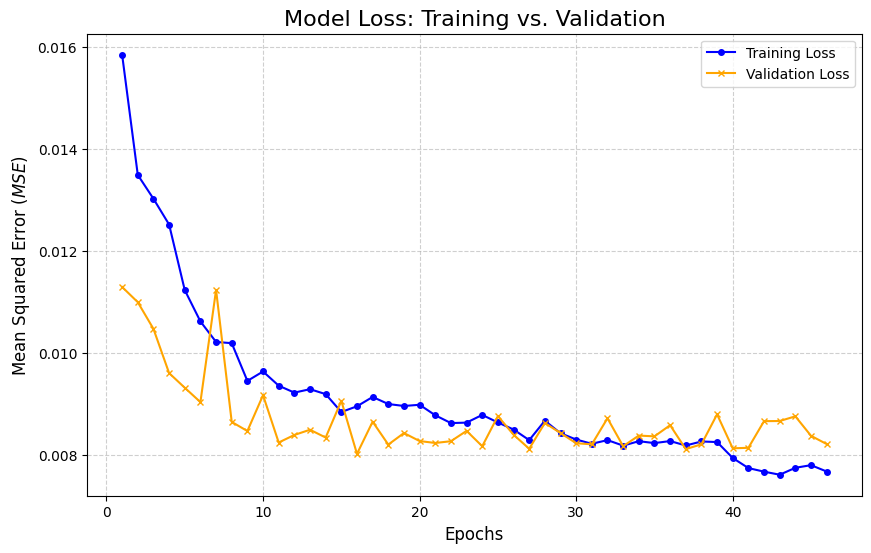

In [12]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', marker='x', markersize=4)
plt.title('Model Loss: Training vs. Validation', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error ($MSE$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
# 1. Put model in evaluation mode
model.eval()

# 3. Predict without calculating gradients
with torch.no_grad():
    preds_t = model(X_val_t)

# 4. Move back to CPU and convert to NumPy for your metrics function
preds = preds_t.cpu().numpy()

# 5. Run the metrics
avg_psnr, avg_ssim = calculate_metrics(y_val, preds)

print(f"Validation PSNR: {avg_psnr:.2f}")
print(f"Validation SSIM: {avg_ssim:.4f}")

Validation PSNR: 18.82
Validation SSIM: 0.7652


In [ ]:
# Save to Google Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/AI_project/underwater_model1.pth')

In [ ]:
loss_history = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
})

loss_history.to_csv('/content/drive/MyDrive/AI_project/loss_results1.csv', index=False)